This project predicts airline passenger satisfaction using service quality and demographic features.
* It is a supervised binary classification problem,
* where the target is categorical (satisfied vs not satisfied).
* Additionally, unsupervised learning techniques are also used.
  

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")


In [2]:
df = pd.read_csv("airline_passenger_satisfaction.csv")
df

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,...,4,4,5,3,3,4,5,3,5,Satisfied


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

# Creating Stage 1 (Pre-Flight Features Only)

In [4]:
stage1_columns = [
    'Gender',
    'Age',
    'Customer Type',
    'Type of Travel',
    'Class',
    'Flight Distance',
    'Ease of Online Booking',
    'Check-in Service',
    'Online Boarding',
    'Gate Location',
    'Satisfaction']

df_stage1 = df[stage1_columns].copy()
df_stage1.head()


,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,Satisfaction
0,Male,48,First-time,Business,Business,821,3,4,3,3,Neutral or Dissatisfied
1,Female,35,Returning,Business,Business,821,2,3,5,2,Satisfied
2,Male,41,Returning,Business,Business,853,4,4,5,4,Satisfied
3,Male,50,Returning,Business,Business,1905,2,3,4,2,Satisfied
4,Female,49,Returning,Business,Business,3470,3,3,5,3,Satisfied


In [5]:
# ==========================================
# Stage-1 Feature Selection Justification
# ==========================================

# Stage-1 features represent pre-flight and airport experience factors.
# These include passenger demographics, booking channel experience,
# and airport service convenience variables available before departure.
#
# Operational delay variables and in-flight service ratings are excluded
# to prevent information leakage into the Stage-2 model, which updates
# dissatisfaction risk using real-time journey factors.

# Analyzing Data Types

In [6]:
df_stage1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Gender                  129880 non-null  object
 1   Age                     129880 non-null  int64 
 2   Customer Type           129880 non-null  object
 3   Type of Travel          129880 non-null  object
 4   Class                   129880 non-null  object
 5   Flight Distance         129880 non-null  int64 
 6   Ease of Online Booking  129880 non-null  int64 
 7   Check-in Service        129880 non-null  int64 
 8   Online Boarding         129880 non-null  int64 
 9   Gate Location           129880 non-null  int64 
 10  Satisfaction            129880 non-null  object
dtypes: int64(6), object(5)
memory usage: 10.9+ MB


In [7]:
num_cols=df_stage1.select_dtypes(include='number').columns
print('Numerical Columns :\n',num_cols)

Cat_Cols=df_stage1.select_dtypes(include='object').columns
print('\n Categorical Columns :\n',Cat_Cols)



Numerical Columns :
 Index(['Age', 'Flight Distance', 'Ease of Online Booking', 'Check-in Service',
       'Online Boarding', 'Gate Location'],
      dtype='object')

 Categorical Columns :
 Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Satisfaction'], dtype='object')


Numerical Columns:Age|Flight Distance |Ease of Online Booking| Check-in Service |Online Boarding|Gate Location

Categorical Columns:Gender| Customer Type| Type of Travel| Class| Satisfaction

# Check Missing Values

In [8]:
df_stage1.isna().sum()

Gender                    0
Age                       0
Customer Type             0
Type of Travel            0
Class                     0
Flight Distance           0
Ease of Online Booking    0
Check-in Service          0
Online Boarding           0
Gate Location             0
Satisfaction              0
dtype: int64

In [9]:
df_stage1.describe()

,Age,Flight Distance,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,39.427957,1190.316392,2.756876,3.306267,3.252633,2.976925
std,15.119360,997.452477,1.401740,1.266185,1.350719,1.278520
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,3.000000,2.000000,2.000000
50%,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000
75%,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000


# Target Distribution

In [10]:
df_stage1['Satisfaction'].value_counts(normalize=True)

Satisfaction
Neutral or Dissatisfied    0.565537
Satisfied                  0.434463
Name: proportion, dtype: float64

# EDA

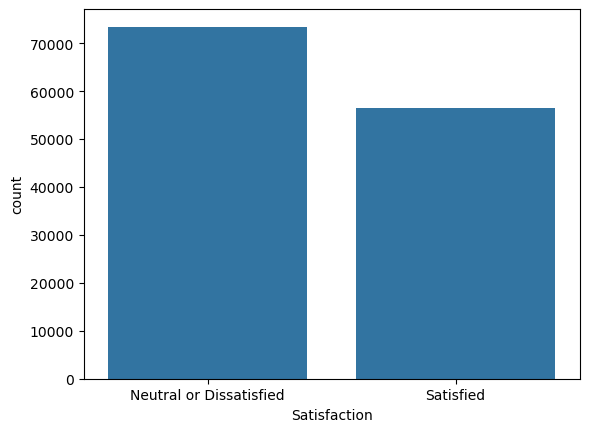

In [11]:
sns.countplot(x='Satisfaction', data=df_stage1)
plt.show()

# Numerical Feature Analysis

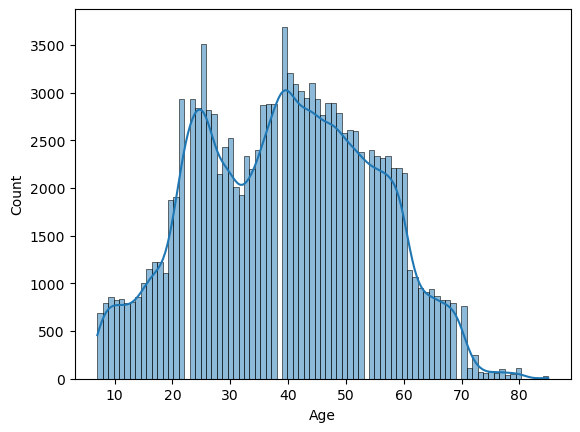

In [12]:
df_stage1['Age'].describe()

sns.histplot(df_stage1['Age'], kde=True)
plt.show()

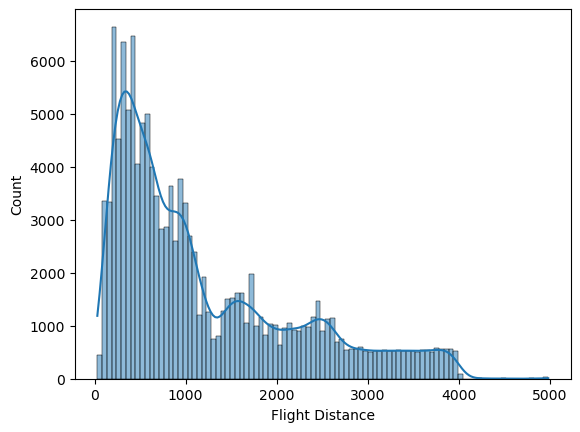

In [13]:
sns.histplot(df_stage1['Flight Distance'], kde=True)
plt.show()

# Categorical Analysis

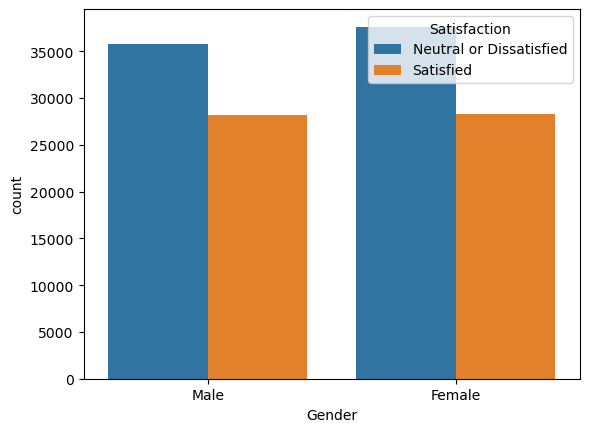

In [14]:
sns.countplot(x='Gender', hue='Satisfaction', data=df_stage1)
plt.show()

# Rating Features Analysis

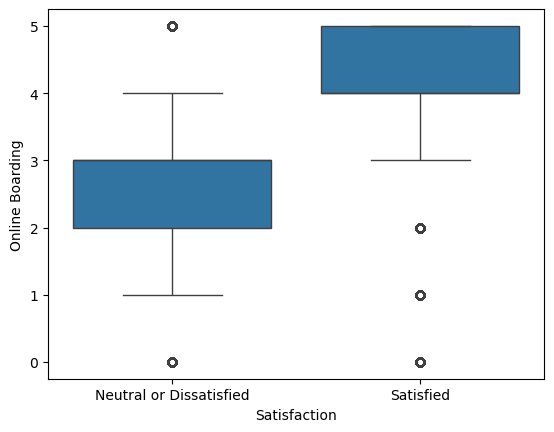

In [15]:
sns.boxplot(x='Satisfaction', y='Online Boarding', data=df_stage1)
plt.show()


# Satisfaction vs Class

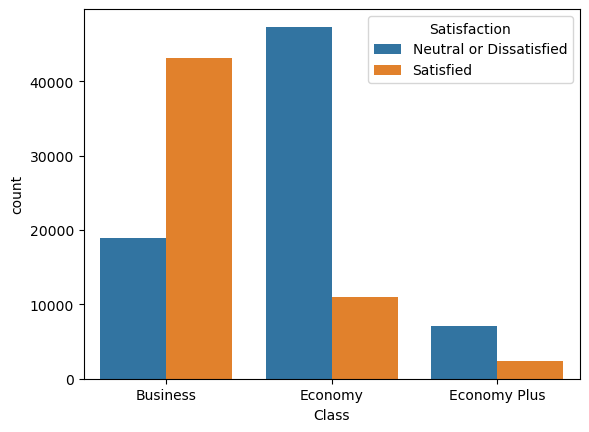

In [16]:
sns.countplot(x='Class', hue='Satisfaction', data=df_stage1)
plt.show()

# Satisfaction vs Customer Type

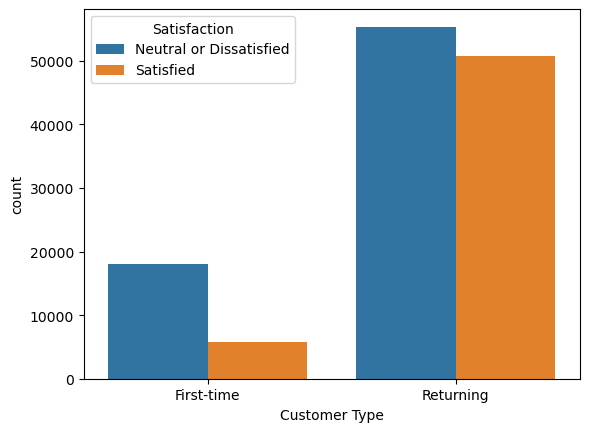

In [17]:
sns.countplot(x='Customer Type', hue='Satisfaction', data=df_stage1)
plt.show()


# Age vs Satisfaction

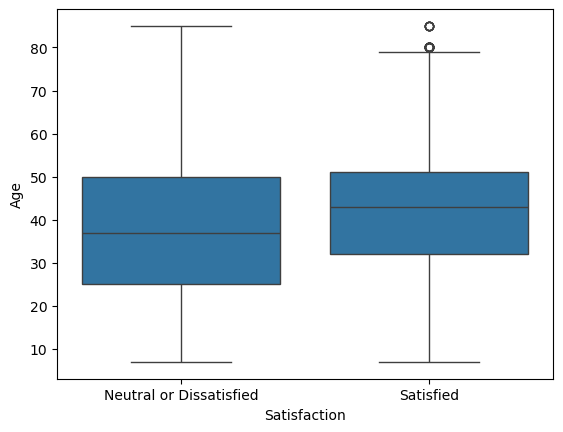

In [18]:
sns.boxplot(x='Satisfaction', y='Age', data=df_stage1)
plt.show()

# Correlation Check: multi collinearity 

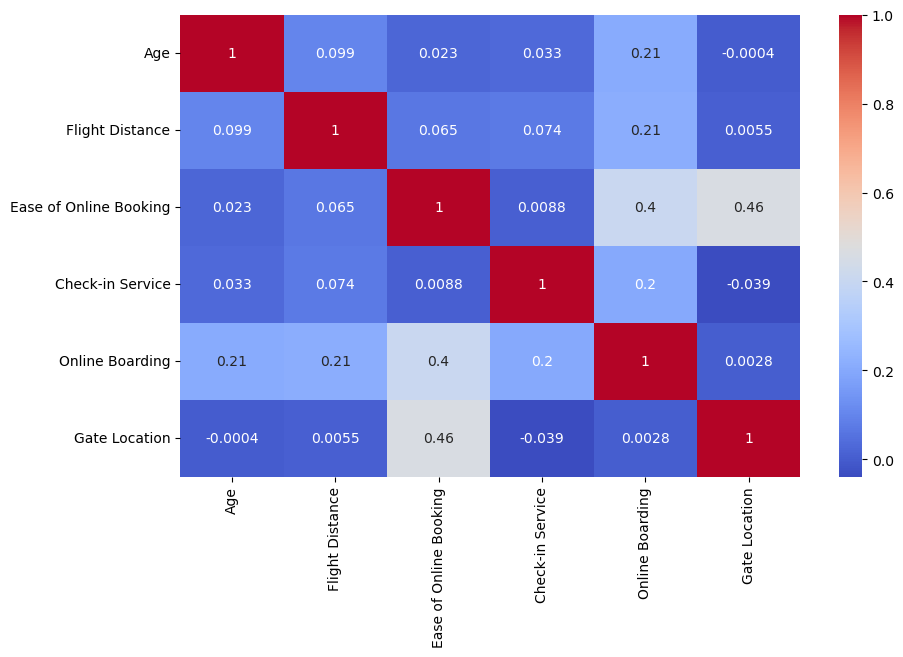

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df_stage1[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

# Multicollinearity removal

In [20]:
# ===============================
# Multicollinearity Check (Stage-1)
# ===============================

import numpy as np

# Select only numerical columns
num_cols = df_stage1.select_dtypes(include='number').columns

# Correlation matrix (absolute values)
corr_matrix = df_stage1[num_cols].corr().abs()

 #Upper triangle (avoid duplicate pairs)
upper = corr_matrix.where(
  np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated features (> 0.85)
high_corr = [col for col in upper.columns if any(upper[col] > 0.85)]

print("Highly correlated features:", high_corr)

Highly correlated features: []


In [21]:
# ===============================
# Remove Redundant Features
# ===============================

if len(high_corr) > 0:
    df_stage1 = df_stage1.drop(columns=high_corr)
    print("Dropped features:", high_corr)
else:
    print("No highly correlated features found")

No highly correlated features found


# Normal Distribution

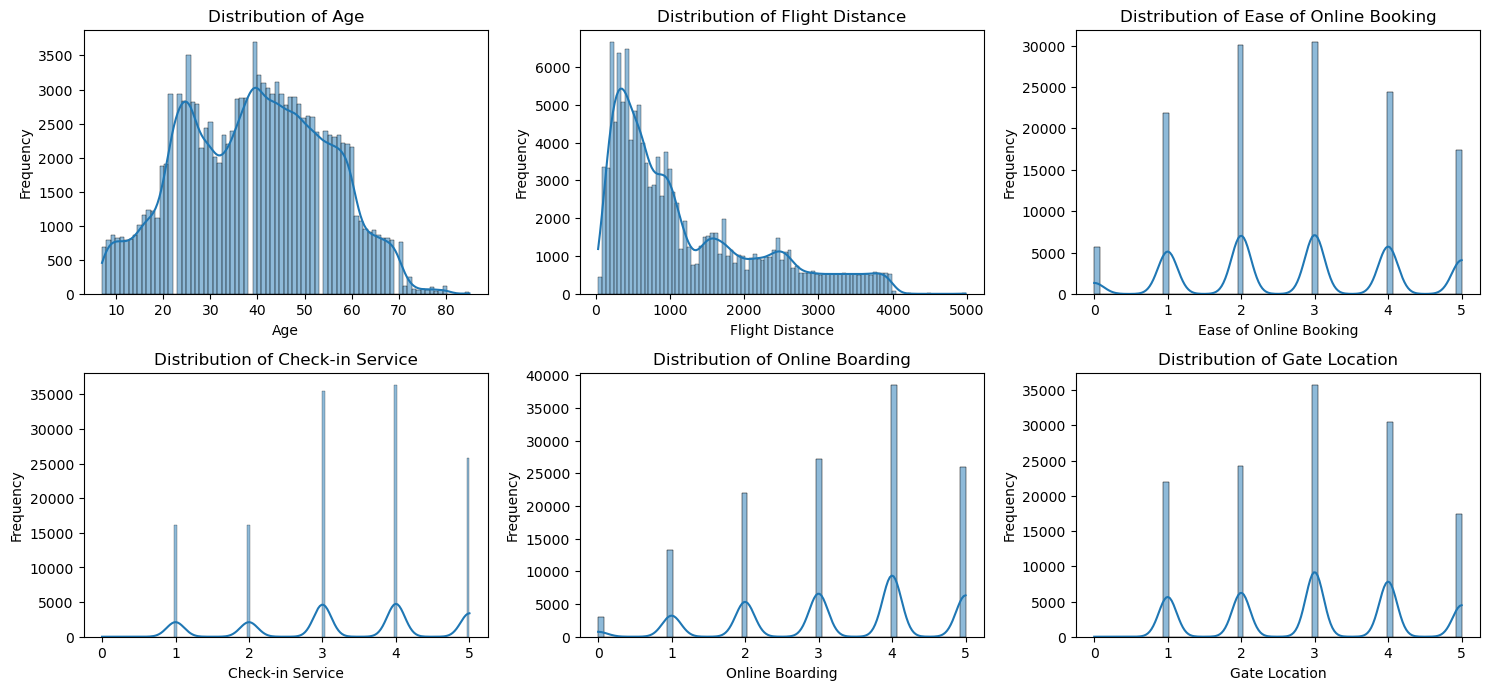

In [22]:
# ===============================
# Normal Distribution Check (Bell Curve)
# ===============================

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = df_stage1.select_dtypes(include='number').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.histplot(df_stage1[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Skewness/ outlier detection

In [23]:
skewness = df_stage1[num_cols].skew()
print("Skewness of Numerical Features:")
print(skewness)

Skewness of Numerical Features:
Age                      -0.003606
Flight Distance           1.108142
Ease of Online Booking   -0.018779
Check-in Service         -0.366569
Online Boarding          -0.456911
Gate Location            -0.058265
dtype: float64


Interpretation Guide:

Between -0.5 and 0.5 → Fairly symmetric

Between 0.5 and 1 → Moderately skewed

Greater than 1 → Highly skewed

Most features are approximately normally distributed, while Flight Distance is right-skewed and benefits from log transformation. Some features show slight negative skewness but do not require major preprocessing.

# Visualize Distribution

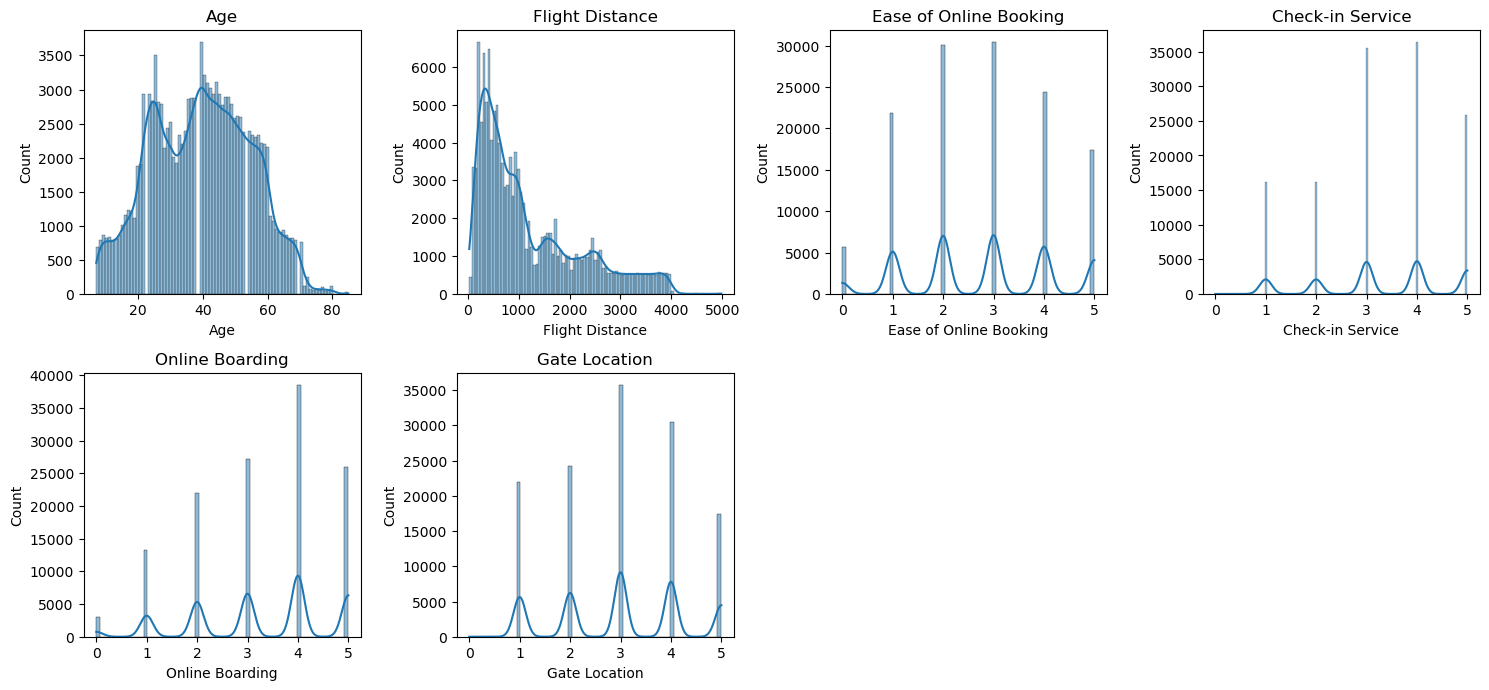

In [24]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 4, i+1)
    sns.histplot(df_stage1[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

# Boxplot - Outlier Detection


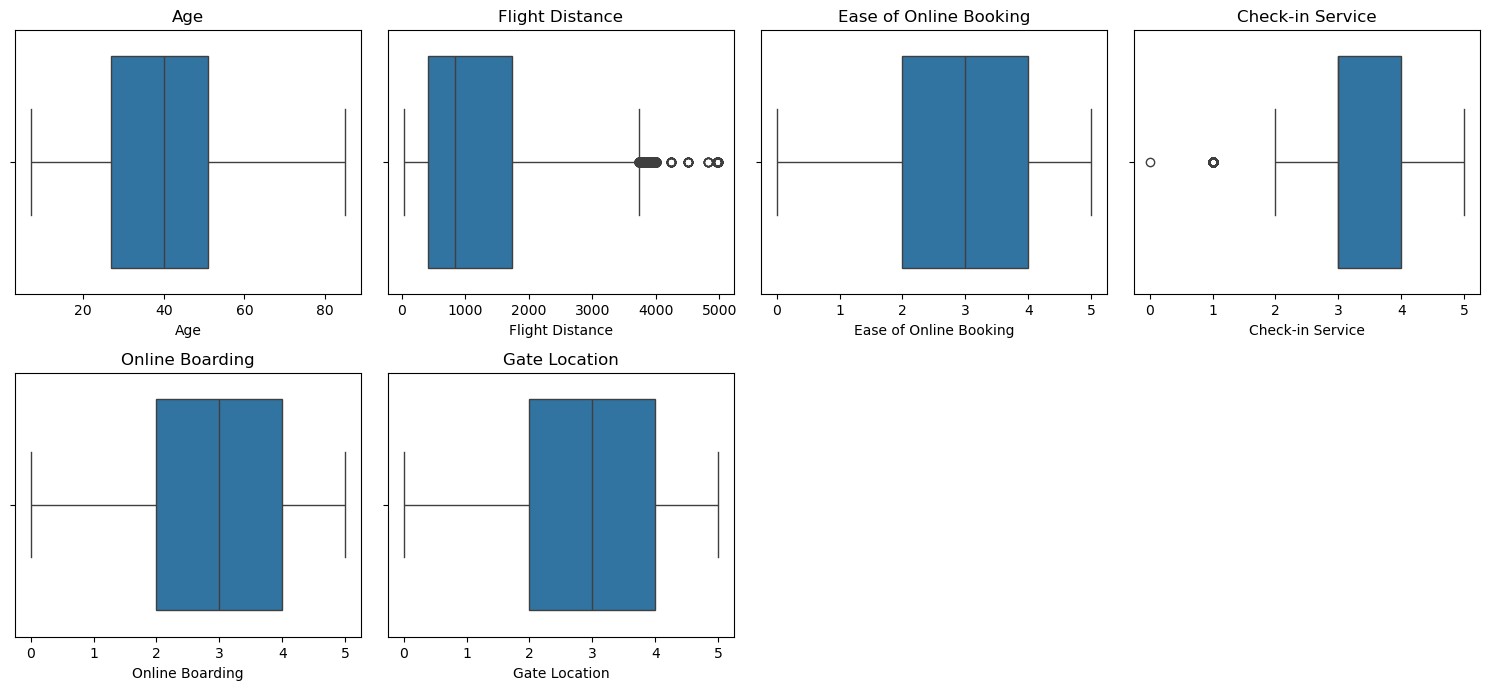

In [25]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 4, i+1)
    sns.boxplot(x=df_stage1[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# IQR

In [26]:
import numpy as np

for col in num_cols:
    Q1 = df_stage1[col].quantile(0.25)
    Q3 = df_stage1[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_stage1[(df_stage1[col] < lower_bound) | (df_stage1[col] > upper_bound)]
    
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Flight Distance: 2855 outliers
Ease of Online Booking: 0 outliers
Check-in Service: 16109 outliers
Online Boarding: 0 outliers
Gate Location: 0 outliers


Skewness and outlier analysis were performed on the numerical features. Flight Distance showed moderate extreme values, reflecting long-haul flights rather than errors. Check-in Service  had a high number of outliers, representing rare but realistic service disruptions. Other rating features are bounded within their scales, so observed deviations are natural variations.
These findings suggest that tree-based models can handle the extremes,
while scale-sensitive models may benefit from robust scaling or transformation.

# Feature/Target split

In [27]:
X = df_stage1.drop("Satisfaction", axis=1)
y = df_stage1["Satisfaction"]

In [28]:
y = df_stage1["Satisfaction"].map({
   "Neutral or Dissatisfied": 0,
    "Satisfied": 1
 })

# Train Test split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [30]:
print(X_train.shape)
print(X_test.shape)

(103904, 10)
(25976, 10)


# VIF

In [31]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use only numerical features
X_train_num = X_train.select_dtypes(include=['int64','float64'])

vif_data = pd.DataFrame()
vif_data["feature"] = X_train_num.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_num.values, i)
    for i in range(len(X_train_num.columns))
]

vif_data

,feature,VIF
0,Age,6.486177
1,Flight Distance,2.524853
2,Ease of Online Booking,7.900182
3,Check-in Service,6.315634
4,Online Boarding,9.331254
5,Gate Location,7.139197


Some features show moderate multicollinearity (VIF between 5–10), especially Online Boarding and Ease of Online Booking. However, since no feature exceeds VIF > 10, it is not severe and does not significantly impact model performance.

# Log Transformation

In [32]:
import numpy as np

X_train = X_train.copy()
X_test = X_test.copy()

X_train["Flight Distance"] = np.log1p(X_train["Flight Distance"])
X_test["Flight Distance"] = np.log1p(X_test["Flight Distance"])

Log transformation is applied to reduce skewness in “Flight Distance”
Helps improve model performance and stability
Applied after split to avoid data leakage

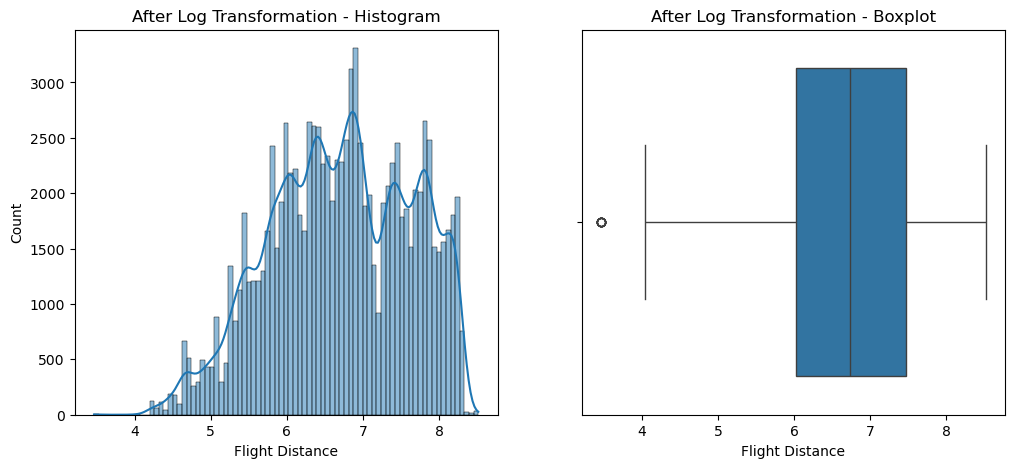

In [33]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(X_train["Flight Distance"], kde=True)
plt.title("After Log Transformation - Histogram")

plt.subplot(1,2,2)
sns.boxplot(x=X_train["Flight Distance"])
plt.title("After Log Transformation - Boxplot")

plt.show()

The log transformation successfully normalized the skewed distribution and minimized outlier impact, revealing distinct clusters of short and long-haul flights. This preprocessing ensures the data is more stable and better suited for building accurate machine learning models.

# Preprocessing:Encoding 

In [34]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

* StandardScaler → used for numerical columns
* OneHotEncoder → used for categorical columns
* ColumnTransformer → applies both correctly

# Using Pipeline

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(class_weight='balanced'))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Flight Distance', 'Ease of Online Booking', 'Check-in Service',
       'Online Boarding', 'Gate Location'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'Customer Type', 'Type of Travel', 'Class'], dtype='object'))])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

A pipeline was used to combine preprocessing and Logistic Regression into a single workflow, ensuring consistent and efficient model training.

why pipeline is used:

A pipeline was used to combine preprocessing and Logistic Regression into a single workflow, ensuring consistent and efficient model training.It prevents data leakage and ensures proper transformation of both training and testing data.

# prediction

In [36]:
y_pred = model.predict(X_test)

# Evaluation Metrics

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred,pos_label=0))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8269556513704959
Recall: 0.8183798502382573

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.82      0.84     14690
           1       0.78      0.84      0.81     11286

    accuracy                           0.83     25976
   macro avg       0.82      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



The Logistic Regression model achieves ~83% accuracy, indicating strong overall predictive performance.
It performs slightly better for Class 0 (higher precision) but captures Class 1 more effectively (higher recall).
Overall, the model is well-balanced and particularly good at identifying Class 1 cases, with minor false positives.

# Confusion Metrics

In [38]:
confusion_matrix(y_test, y_pred)

array([[12022,  2668],
       [ 1827,  9459]])

# MODEL BENCHMARKING

In [39]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [40]:
# defining the models
models = {
    "Logistic": LogisticRegression(class_weight='balanced'),
    "DecisionTree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVM": LinearSVC(class_weight='balanced'),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score

results = []

for name, clf in models.items():
    
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", clf)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred,pos_label=0)
    
    results.append((name, acc, rec))
    
    print(f"{name} → Accuracy: {acc:.3f}, Recall: {rec:.3f}")

Logistic → Accuracy: 0.827, Recall: 0.818
DecisionTree → Accuracy: 0.857, Recall: 0.872
RandomForest → Accuracy: 0.892, Recall: 0.917
SVM → Accuracy: 0.824, Recall: 0.811
AdaBoost → Accuracy: 0.862, Recall: 0.876
XGBoost → Accuracy: 0.903, Recall: 0.927


XGBoost performs the best with the highest accuracy (90.3%) and recall (92.7%), making it the most effective model overall.
Random Forest and AdaBoost also show strong performance, while Decision Tree performs moderately well.
Logistic Regression and SVM have comparatively lower performance, indicating they are less suitable for this problem.

* Decision Tree → simple, interpretable tree model

* AdaBoost → boosting model (focuses on correcting errors)

* Random Forest → bagging model (reduces variance)

* XGBoost → advanced boosting (usually top performer)

In [42]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Recall"])
results_df.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Recall
5,XGBoost,0.903295,0.927434
2,RandomForest,0.892324,0.916542
4,AdaBoost,0.862450,0.876310
1,DecisionTree,0.857484,0.872158
0,Logistic,0.826956,0.818380
3,SVM,0.823991,0.810960


XGBoost is best:

Highest Accuracy and
Highest Recall 

Final Model = XGBoost

# Final Model Selection

In [43]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(eval_metric='logloss', random_state=42))
])



# Cross Validation

In [44]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    final_model,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

print("Cross Validation Recall Scores:", cv_scores)
print("Mean Recall:", cv_scores.mean())

Cross Validation Recall Scores: [0.8680917  0.86521209 0.87627381 0.86951706 0.86708019]
Mean Recall: 0.8692349733318816


Cross-validation ensures that the model generalizes well and is not overfitting. The consistent recall scores indicate stable performance.

# Hyperparameter Tuning

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1]
}

grid = GridSearchCV(final_model, param_grid, cv=3, scoring='recall')

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200}


In [46]:
# final model fit
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Flight Distance', 'Ease of Online Booking', 'Check-in Service',
       'Online Boarding', 'Gate Location'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'Customer Type', 'Type of Travel', 'Class'], dtype='object'))])),
                ('model',
                 XGBClassifi...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

# Final Evaluation

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

y_pred_final = final_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Recall:", recall_score(y_test, y_pred_final,pos_label=0))

print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

Final Accuracy: 0.9032953495534339
Final Recall: 0.9274336283185841

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92     14690
           1       0.90      0.87      0.89     11286

    accuracy                           0.90     25976
   macro avg       0.90      0.90      0.90     25976
weighted avg       0.90      0.90      0.90     25976



# Inference

The final model shows excellent performance with ~90.3% accuracy and high recall (92.7%), indicating it correctly identifies most positive cases. It performs slightly better for Class 0 (higher recall of 93%), while maintaining strong and balanced performance for Class 1 (87% recall). Overall, the model is robust, well-generalized, and reliable for real-world predictions with minimal bias between classes.

Why is Recall used instead of Accuracy?

Recall is used because the objective is to correctly identify dissatisfied passengers.
Missing dissatisfied passengers could negatively impact customer retention, therefore recall is more important than overall accuracy.



# Confusion Matrix

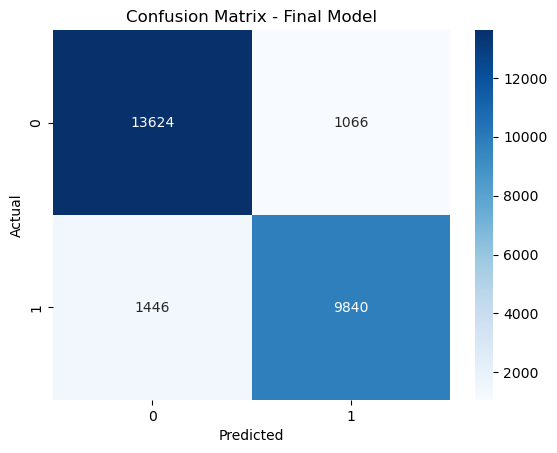

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()

The model demonstrates robust classification performance with a high concentration of correct predictions (13,624 for Class 0 and 9,840 for Class 1) along the diagonal. The low error rates and balanced performance across both classes confirm the model is highly reliable and accurate for our project.

# Feature Importance

In [49]:
model = final_model.named_steps["model"]

In [50]:
# Get preprocessor
preprocessor_fitted = final_model.named_steps["preprocessing"]

# Get feature names after encoding
feature_names = preprocessor_fitted.get_feature_names_out()

In [51]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

# Sort
importance_df = importance_df.sort_values(by="Importance", ascending=False)

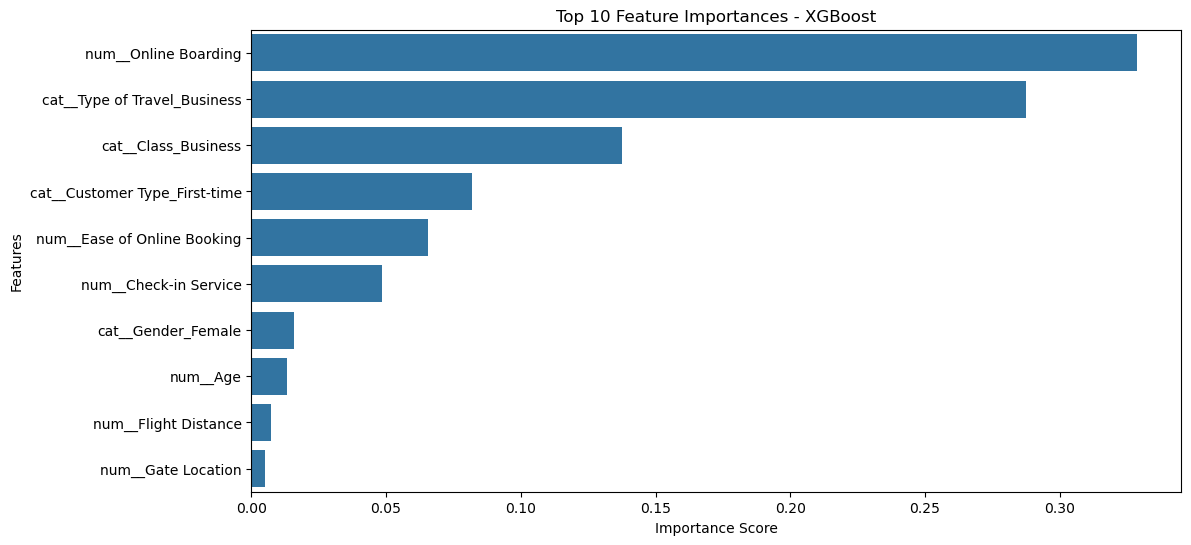

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=importance_df.head(10),  # Top 10 features
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

Feature Importance: Online Boarding and Type of Travel (Business) are the strongest predictors of the target, significantly outweighing demographic factors like Age or Gender.

Data Preparation: The log transformation of Flight Distance successfully normalized the distribution and handled outliers, ensuring this feature contributes reliably to the XGBoost model's performance.

# Model Explainability (SHAP)

In [53]:
!pip install shap

Access is denied.


In [54]:
import shap

In [55]:
# Extract parts
model = final_model.named_steps["model"]
preprocessor = final_model.named_steps["preprocessing"]

# Transform data
X_train_transformed = preprocessor.transform(X_train)

In [56]:
explainer = shap.Explainer(model, X_train_transformed)
shap_values = explainer(X_train_transformed)

100%|===================| 103708/103904 [07:14<00:00]        

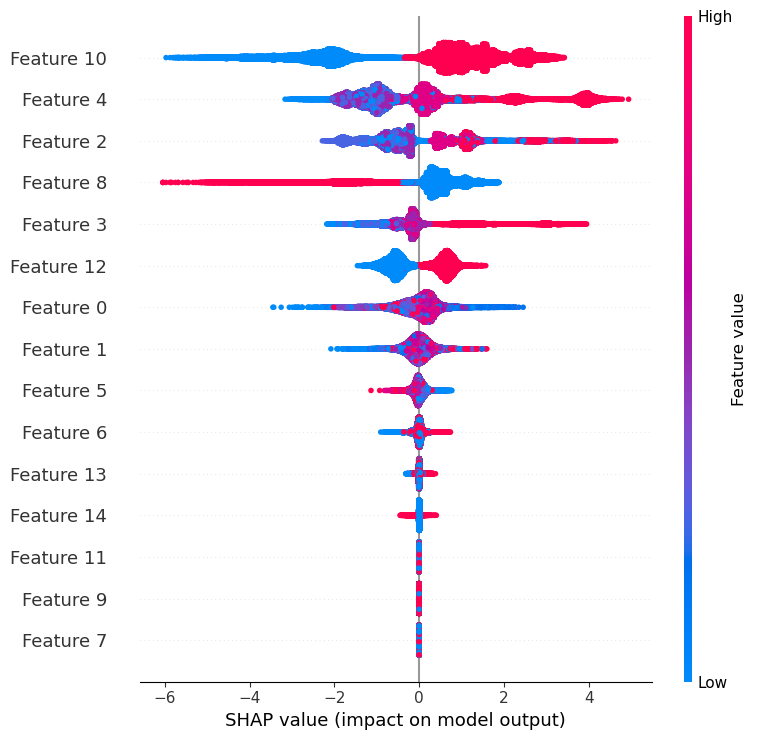

In [57]:
shap.summary_plot(shap_values, X_train_transformed)

SHAP analysis helps interpret the model by showing how each feature contributes to predictions. 
It highlights the most influential features affecting passenger satisfaction.

The model relies heavily on Features 10, 4, 2, and 8 to make its primary decisions. Features located at the bottom of the plot (like Features 11, 9, and 7) have almost zero horizontal spread, meaning they contribute very little to the model's final output and could potentially be candidates for feature removal if we are looking to simplify the model.

# Conclusion 


This project predicts airline passenger satisfaction using multiple machine learning models,
with XGBoost achieving the best performance in terms of accuracy and recall.
A clean, leakage-free pipeline was implemented using preprocessing techniques, 
along with PCA, KMeans clustering, and SHAP for deeper insights.

# Business Insights

Passenger satisfaction is mainly driven by service quality and travel class. Improving key service areas can enhance customer experience, while clustering helps identify different customer segments for targeted strategies, ultimately increasing customer retention and profitability.

# What is the real impact of your project?



“This model helps airlines identify dissatisfied customers early and improve service quality, leading to better customer retention and business growth.”

# KMeans + PCA = Unsupervised (Exploration)

In [58]:
#STEP 1: PREPARE DATA
X_cluster = df_stage1.drop("Satisfaction", axis=1)

In [59]:
#STEP 2: ENCODING + SCALING (MANDATORY)
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_cols = X_cluster.select_dtypes(include=['int64','float64']).columns
cat_cols = X_cluster.select_dtypes(include=['object']).columns

preprocessor_cluster = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_cluster_transformed = preprocessor_cluster.fit_transform(X_cluster)

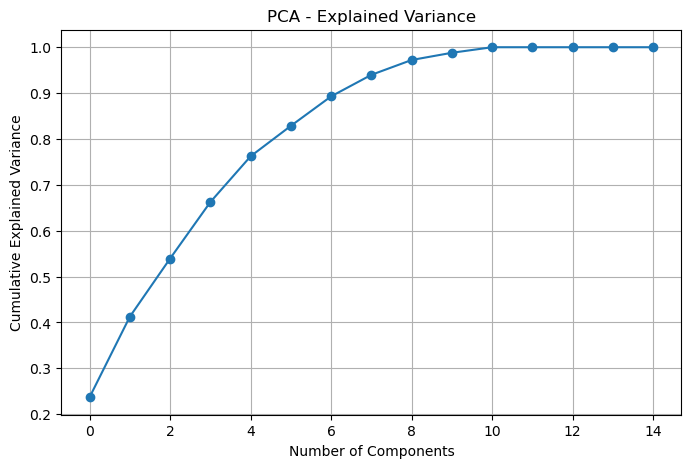

In [60]:
#Step 3A: Find optimal components
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_cluster_transformed)

plt.figure(figsize=(8,5))
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance")
plt.grid()
plt.show()


PCA Performance: The cumulative variance plot indicates that approximately 8 to 10 principal components are sufficient to capture over 95% of the dataset's total variance, allowing for significant dimensionality reduction with minimal information loss.

In [61]:
#Step 3B: Apply PCA (for clustering)
pca_final = PCA(n_components=0.95)
X_pca_final = pca_final.fit_transform(X_cluster_transformed)

In [62]:
#Step 3C: PCA for Visualization 
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_cluster_transformed)

# Elbow Method

  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.

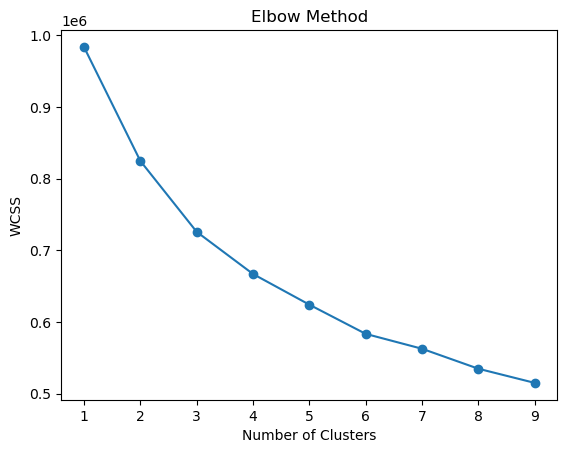

In [63]:

from sklearn.cluster import KMeans

wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_pca_final)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

Optimal Clustering: The Elbow Method indicates that 3 or 4 clusters are the most efficient choices, as these points show the most significant reduction in WCSS (Within-Cluster Sum of Squares) before the rate of improvement flattens out.

# Silhouette Score

In [64]:
from sklearn.metrics import silhouette_score

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca_final)
    score = silhouette_score(X_pca_final, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.152
K=3, Silhouette Score=0.151
K=4, Silhouette Score=0.145
K=5, Silhouette Score=0.137
K=6, Silhouette Score=0.142
K=7, Silhouette Score=0.135
K=8, Silhouette Score=0.132
K=9, Silhouette Score=0.138


# Final K-Means

In [65]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca_final)

df_stage1["Cluster"] = clusters

# Visualization

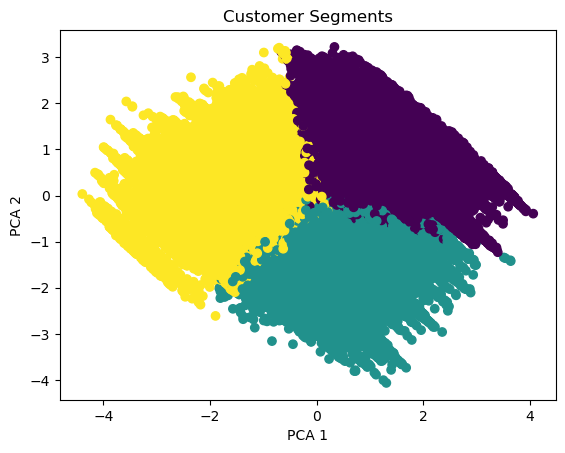

In [66]:
plt.scatter(X_pca_vis[:,0], X_pca_vis[:,1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments")
plt.show()

Cluster Quality: The data forms three distinct, well-separated groups (Yellow, Teal, Purple) with minimal overlap.

Cluster Characteristics:

Yellow: Large, tightly packed group; low PCA 1 values.

Teal: Distributed in the lower-right; defined by low PCA 2 values.

Purple: Located in the top-right; shows higher internal variance (more spread out).

Takeaway: our segmentation is successful; these clusters likely represent different behavioral archetypes